# Results postprocessing

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Joining folders

In [39]:
import os

for folder in os.listdir('../'):
    if folder.startswith('results_'):
        folder_results_name = os.path.join('../', folder)
        sufix = '_'.join(folder.split('_')[1:])

        qtd_folders = sum(1 for x in os.listdir(folder_results_name) if os.path.isdir(os.path.join(folder_results_name, x)))
        if qtd_folders == 7:
            print('Folder {} already has been processed, skipping...'.format(folder_results_name))
            continue
        
        folders = os.listdir(folder_results_name).copy()
        for folder_model in folders:
            parts = folder_model.split('_')
            new_folder_name = parts[2] + '_' + sufix
            
            if not os.path.exists(os.path.join(folder_results_name, new_folder_name)):
                os.mkdir(os.path.join(folder_results_name, new_folder_name))

            os.rename(os.path.join(folder_results_name, folder_model), os.path.join(folder_results_name, new_folder_name, folder_model))

Folder ../results_triage_both_2imgs already has been processed, skipping...
Folder ../results_triage_dermatoscope already has been processed, skipping...
Folder ../results_triage_clinical already has been processed, skipping...
Folder ../results_triage_both already has been processed, skipping...


## Getting metrics

In [40]:
df = pd.DataFrame(columns=["backbone", "classifier", "image_type", "folder", "metric", "metric_value", "classifier_type"])
df_pred = pd.DataFrame(columns=["backbone", "classifier", "image_type", "folder", "y_true", "y_pred", "classifier_type"])

In [41]:
def getMetrics(path):
    with open(path, "r") as f:
        lines = f.read().split("\n")
        acc = float(lines[3].split(": ")[1])
        bacc = float(lines[5].split(": ")[1])

        auc_line = len(lines)
        if 'AUC' in lines[auc_line-1]:
            auc_line = auc_line-1
        elif 'AUC' in lines[auc_line-2]:
            auc_line = auc_line-2
        
        auc = float(lines[auc_line].split(": ")[1])
        
        for line in lines[22:]:
            if "macro avg" in line:
                f1_macro = float([x for x in line.split(" ") if x.strip() != ""][-2])
    
        return [('acc', acc), ('bacc', bacc), ('f1_macro', f1_macro), ('auc', auc)]

In [42]:
def getDfPred(path, classifier, backbone, image_type, folder, classifier_type):
    df_aux = pd.read_csv(path)
    df_aux = df_aux[["PRED", "REAL"]]
    df_aux = df_aux.rename(columns={"PRED": "y_pred", "REAL": "y_true"})
    df_aux['classifier'] = classifier
    df_aux['backbone'] = backbone
    df_aux['image_type'] = image_type
    df_aux['folder'] = folder
    df_aux['classifier_type'] = classifier_type
    return df_aux

In [43]:
base_path = '../'
for file in os.listdir(base_path):
    if os.path.isdir(os.path.join(base_path, file)) and file.startswith("results_"):
        path = os.path.join(base_path, file)
        parts = file.split("_")
        classifier = parts[1]
        image_type = parts[2]
        classifier_type = 'normal'
        
        for subfile in os.listdir(path):
            path2 = os.path.join(path, subfile)
            if os.path.isdir(path2):
                parts = subfile.split("_")
                backbone = parts[0]

                for folder in os.listdir(path2):
                    path3 = os.path.join(path2, folder)
                    if os.path.isdir(path3):
                        folder_number = folder.split("_")[-2]
                        flag_special_case = False

                        results_path = os.path.join(path3, "best_metrics")

                        try:
                            results = getMetrics(os.path.join(results_path, "metrics.txt"))
                        except:
                            results_path = os.path.join(path3, "test_pred_CNN")
                            results = getMetrics(os.path.join(results_path, "metrics.txt"))
                            flag_special_case = True

                        for metric in results:
                            new_row = {
                                "backbone": backbone,
                                "classifier": classifier,
                                "image_type": image_type,
                                "folder": folder_number,
                                "metric": metric[0],
                                "metric_value": metric[1],
                                "classifier_type": classifier_type,
                            }
                            df.loc[len(df)] = new_row

                        pred_path = os.path.join(results_path, "predictions_best_test.csv")
                        df_aux = getDfPred(pred_path, classifier, backbone, image_type, folder_number, classifier_type)
                        df_pred = pd.concat([df_pred, df_aux], ignore_index=True)

                        if flag_special_case == True:
                            results_path = os.path.join(path3, "test_pred_SVM")
                            classifier_type = 'svm'

                            results = getMetrics(os.path.join(results_path, "metrics.txt"))
                            for metric in results:
                                new_row = {
                                    "backbone": backbone,
                                    "classifier": classifier,
                                    "image_type": image_type,
                                    "folder": folder_number,
                                    "metric": metric[0],
                                    "metric_value": metric[1],
                                    "classifier_type": classifier_type,
                                }
                                df.loc[len(df)] = new_row

                            pred_path = os.path.join(results_path, "predictions_best_test.csv")
                            df_aux = getDfPred(pred_path, classifier, backbone, image_type, folder_number, classifier_type)
                            df_pred = pd.concat([df_pred, df_aux], ignore_index=True)

In [44]:
df['backbone'] = df['backbone'].map({
    'resnet-50': 'ResNet-50',
    'mobilenet-v3': 'MobileNet-v3',
    'efficientnet-b4': 'EfficientNet-b4',
    'caformer': 'Caformer-s18',
    'davit': 'Davit-tiny',
    'maxvit': 'Maxvit-tiny',
    'mvitv2': 'Mvit2-small'
})

df_pred['backbone'] = df_pred['backbone'].map({
    'resnet-50': 'ResNet-50',
    'mobilenet-v3': 'MobileNet-v3',
    'efficientnet-b4': 'EfficientNet-b4',
    'caformer': 'Caformer-s18',
    'davit': 'Davit-tiny',
    'maxvit': 'Maxvit-tiny',
    'mvitv2': 'Mvit2-small'
})

## Postprocessing results

### Train Clinical and Dermatoscope

In [45]:
def gerar_tabelas_latex(df, output_path='tabelas_overleaf.txt'):
    # Função interna para montar a tabela de um classificador específico
    def montar_tabela(df_class, nome_classificador):
        # 1. Agrupar os dados para calcular a média e o desvio padrão entre os "folders"
        df_agg = df_class.groupby(['backbone', 'image_type', 'metric'])['metric_value'].agg(['mean', 'std']).reset_index()
        
        # 2. Formatar as métricas no padrão matemático "média \pm std"
        df_agg['valor_formatado'] = df_agg.apply(
            lambda x: f"${x['mean']:.2f} \\pm {x['std']:.2f}$" if pd.notna(x['std']) else f"${x['mean']:.2f}$", 
            axis=1
        )
        
        # 3. Pivotar o dataframe: linhas=backbone, colunas=[image_type, metric]
        df_pivot = df_agg.pivot(index='backbone', columns=['image_type', 'metric'], values='valor_formatado')
        
        # 4. Forçar a ordem exata solicitada (Clinical primeiro, Dermatoscope depois)
        metricas_ordem = ['bacc', 'acc', 'auc', 'f1_macro']
        ordem_colunas = [('clinical', m) for m in metricas_ordem] + [('dermatoscope', m) for m in metricas_ordem]
        
        # Filtrar para evitar erro caso alguma métrica esteja faltando nos dados
        colunas_validas = [col for col in ordem_colunas if col in df_pivot.columns]
        df_pivot = df_pivot[colunas_validas]
        
        # 5. Construir o código LaTeX linha por linha
        linhas_latex = [
            "\\begin{table}[htbp]",
            "    \\centering",
            f"    \\caption{{Resultados de avaliação do classificador de {nome_classificador.capitalize()}.}}",
            f"    \\label{{tab:resultados_{nome_classificador}}}",
            "    \\resizebox{\\textwidth}{!}{",
            "    \\begin{tabular}{l" + "c" * len(colunas_validas) + "}",
            "        \\toprule",
            "        \\multirow{2}{*}{\\textbf{Backbone}} & \\multicolumn{4}{c}{\\textbf{Clinical}} & \\multicolumn{4}{c}{\\textbf{Dermatoscope}} \\\\",
            "        \\cmidrule(lr){2-5} \\cmidrule(lr){6-9}"
        ]
        
        # Montar a segunda linha do cabeçalho (nomes das métricas)
        cabecalho_metricas = " & ".join([f"\\textbf{{{m[1].upper()}}}" for m in colunas_validas])
        linhas_latex.append(f"         & {cabecalho_metricas} \\\\")
        linhas_latex.append("        \\midrule")
        
        # Preencher as linhas com os dados
        for backbone, row in df_pivot.iterrows():
            valores = " & ".join([str(v) if pd.notna(v) else "-" for v in row.values])
            linhas_latex.append(f"        \\textbf{{{backbone}}} & {valores} \\\\")
            
        # Fechar a tabela
        linhas_latex.extend([
            "        \\bottomrule",
            "    \\end{tabular}",
            "    }",
            "\\end{table}"
        ])
        
        return "\n".join(linhas_latex)

    # Filtrar dados para Triage e Diag e gerar o código de cada um
    df_triage = df[df['classifier'] == 'triage']
    df_triage = df_triage[df_triage['image_type'] != 'both']
    tabela_triage = montar_tabela(df_triage, 'triage') if not df_triage.empty else "% Sem dados disponíveis para triage"
    
    df_diag = df[df['classifier'] == 'diag']
    df_diag = df_diag[df_diag['image_type'] != 'both']
    tabela_diag = montar_tabela(df_diag, 'diag') if not df_diag.empty else "% Sem dados disponíveis para diag"
    
    # Salvar no arquivo TXT
    conteudo_final = f"% --- TABELA: TRIAGE ---\n\n{tabela_triage}\n\n\n% --- TABELA: DIAG ---\n\n{tabela_diag}\n"
    
    with open(output_path, 'w') as f:
        f.write(conteudo_final)
        
    print(f"Arquivo salvo com sucesso em: {output_path}")

# Como executar:
# gerar_tabelas_latex(df, 'tabelas_overleaf.txt')

In [46]:
gerar_tabelas_latex(df, output_path='tabelas_train.txt')

Arquivo salvo com sucesso em: tabelas_train.txt


### Train Both

In [47]:
def gerar_tabelas_latex_both(df, output_path='tabelas_overleaf_both.txt'):
    # Função interna para montar a tabela de um classificador específico
    def montar_tabela(df_class, nome_classificador):
        # 1. Agrupar os dados para calcular a média e o std (sem agrupar por image_type agora)
        df_agg = df_class.groupby(['backbone', 'metric'])['metric_value'].agg(['mean', 'std']).reset_index()
        
        # 2. Formatar as métricas no padrão matemático
        df_agg['valor_formatado'] = df_agg.apply(
            lambda x: f"${x['mean']:.2f} \\pm {x['std']:.2f}$" if pd.notna(x['std']) else f"${x['mean']:.2f}$", 
            axis=1
        )
        
        # 3. Pivotar o dataframe: linhas=backbone, colunas=metric
        df_pivot = df_agg.pivot(index='backbone', columns='metric', values='valor_formatado')
        
        # 4. Forçar a ordem exata das métricas
        metricas_ordem = ['bacc', 'acc', 'auc', 'f1_macro']
        colunas_validas = [m for m in metricas_ordem if m in df_pivot.columns]
        df_pivot = df_pivot[colunas_validas]
        
        # Prepara os nomes das colunas, tratando o caso do F1-score para F1_MACRO
        cabecalhos_formatados = []
        for m in colunas_validas:
            nome = m.upper()
            if nome == 'F1_MACRO':
                nome = 'F1-MACRO'  # Já escapando o underline
            cabecalhos_formatados.append(nome)
            
        # 5. Construir o código LaTeX
        linhas_latex = [
            "\\begin{table}[htbp]",
            "    \\centering",
            f"    \\caption{{Resultados de avaliação do classificador de {nome_classificador.capitalize()} (Imagens Combinadas).}}",
            f"    \\label{{tab:resultados_{nome_classificador}_both}}",
            "    \\resizebox{\\textwidth}{!}{",
            "    \\begin{tabular}{l" + "c" * len(colunas_validas) + "}",
            "        \\toprule",
            "        \\textbf{Backbone} & " + " & ".join([f"\\textbf{{{m}}}" for m in cabecalhos_formatados]) + " \\\\",
            "        \\midrule"
        ]
        
        # Preencher as linhas com os dados
        for backbone, row in df_pivot.iterrows():
            valores = " & ".join([str(v) if pd.notna(v) else "-" for v in row.values])
            linhas_latex.append(f"        \\textbf{{{backbone}}} & {valores} \\\\")
            
        # Fechar a tabela
        linhas_latex.extend([
            "        \\bottomrule",
            "    \\end{tabular}",
            "    }",
            "\\end{table}"
        ])
        
        return "\n".join(linhas_latex)

    # Filtrar dados para Triage e Diag e gerar o código de cada um
    df_triage = df[df['classifier'] == 'triage']
    df_triage = df_triage[df_triage['image_type'] == 'both']
    tabela_triage = montar_tabela(df_triage, 'triage') if not df_triage.empty else "% Sem dados disponíveis para triage"
    
    df_diag = df[df['classifier'] == 'diag']
    df_diag = df_diag[df_diag['image_type'] == 'both']
    tabela_diag = montar_tabela(df_diag, 'diag') if not df_diag.empty else "% Sem dados disponíveis para diag"
    
    # Salvar no arquivo TXT
    conteudo_final = f"% --- TABELA: TRIAGE (BOTH) ---\n\n{tabela_triage}\n\n\n% --- TABELA: DIAG (BOTH) ---\n\n{tabela_diag}\n"
    
    with open(output_path, 'w') as f:
        f.write(conteudo_final)
        
    print(f"Arquivo salvo com sucesso em: {output_path}")

In [48]:
gerar_tabelas_latex_both(df, output_path='tabelas_train_both.txt')

Arquivo salvo com sucesso em: tabelas_train_both.txt


### Confusion Matrix

In [73]:
def plot_comparative_confusion_matrix(df, backbone_target, classifier_target, save_image=False):

    labels = []
    if classifier_target == 'diag':
        labels = ['ACT', 'CBC', 'CEC', 'MEL', 'NEVO', 'SEBO']
    elif classifier_target == 'triage':
        labels = ['P1', 'P2', 'P3', 'P4', 'P5']
    tipos_imagem = ['clinical', 'dermatoscope']

    df_filtered = df[(df['backbone'] == backbone_target) & 
                     (df['classifier'] == classifier_target)]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    # fig.suptitle(f'Resultados obtidos pelo backbone {backbone_target}', fontsize=16)

    for i, img_type in enumerate(tipos_imagem):
        ax = axes[i]
        
        data = df_filtered[df_filtered['image_type'] == img_type]
        
        if not data.empty:
            cm = confusion_matrix(data['y_true'], data['y_pred'], labels=labels, normalize='true')
            
            # Renderização com Seaborn
            sns.heatmap(cm, annot=True, fmt='.2', cmap='YlGnBu', ax=ax,
                        xticklabels=labels, yticklabels=labels, cbar=True)
            
            img_dic = {
                'clinical' : 'Modal Clínica',
                'dermatoscope' : 'Modal Dermatoscópica'
            }
            
            ax.set_title(f'{img_dic[img_type]}', fontsize=16)
            ax.set_ylabel('Classe Verdadeira', fontsize=14)
            ax.set_xlabel('Classe Predita', fontsize=14)

        else:
            ax.text(0.5, 0.5, f'Sem dados para {img_type}', ha='center', va='center')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_image:
        plt.savefig(f'matriz_confusao_{backbone_target}', dpi=300, bbox_inches='tight')
    plt.show()



#### Maxvit-tiny

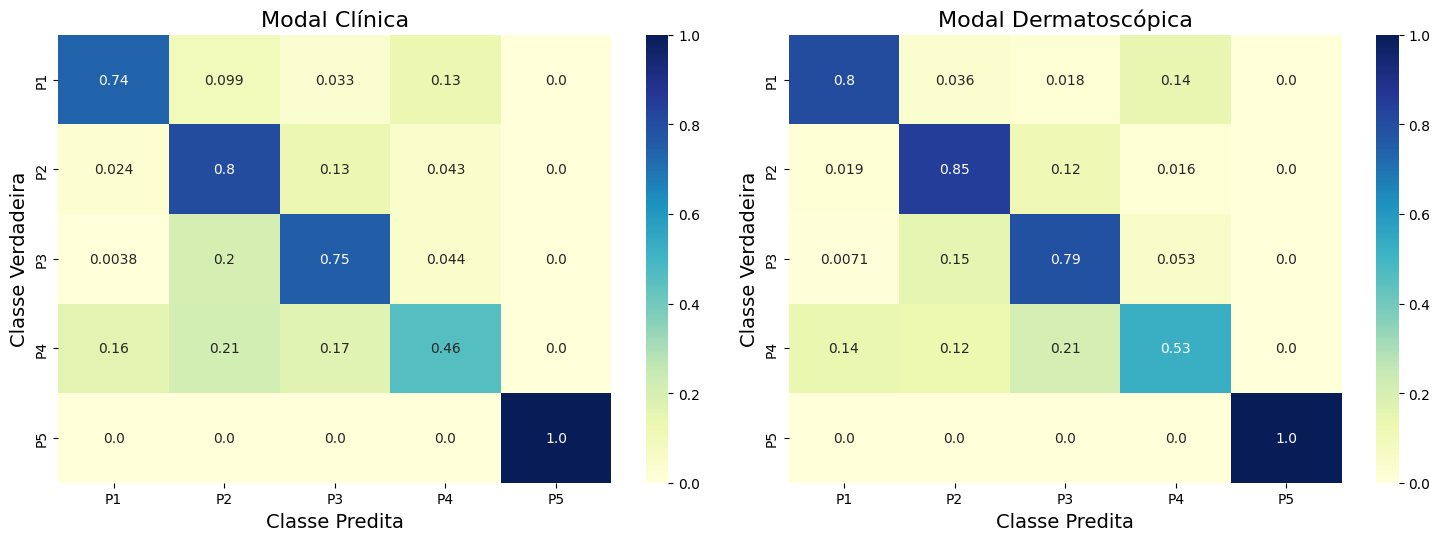

In [74]:
plot_comparative_confusion_matrix(df_pred, "Maxvit-tiny", "triage", True)

#### Resnet-50

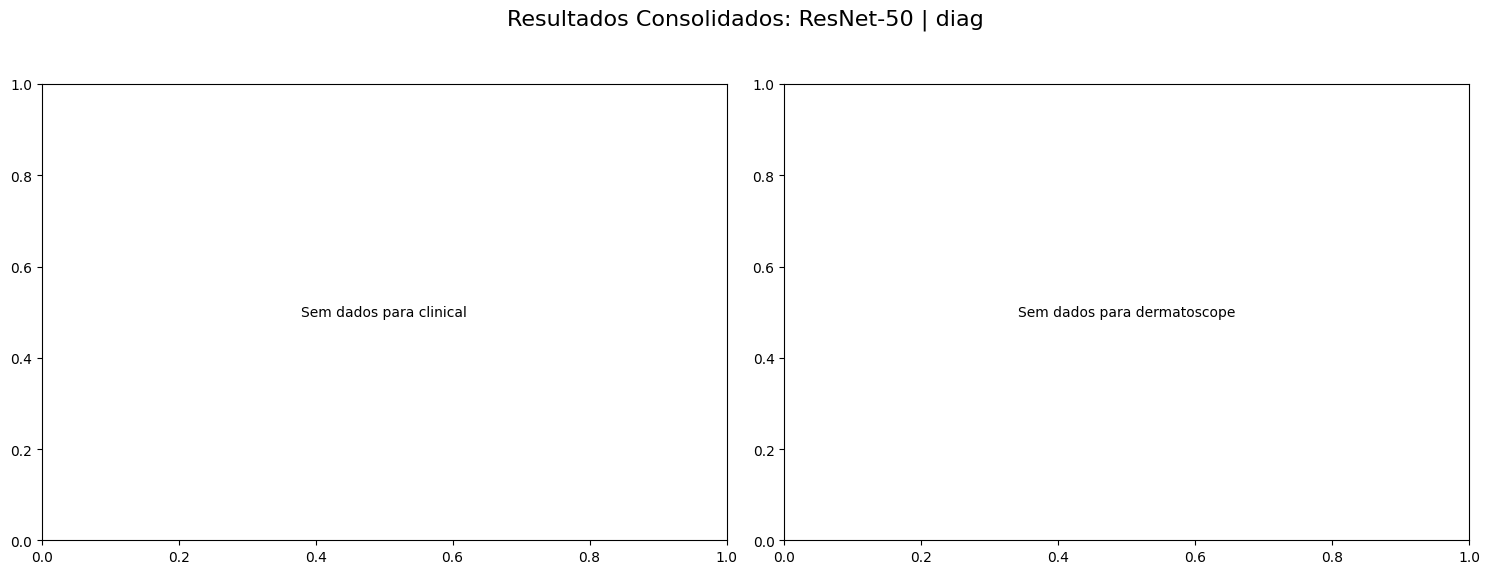

In [50]:
plot_comparative_confusion_matrix(df_pred, "ResNet-50", "diag")

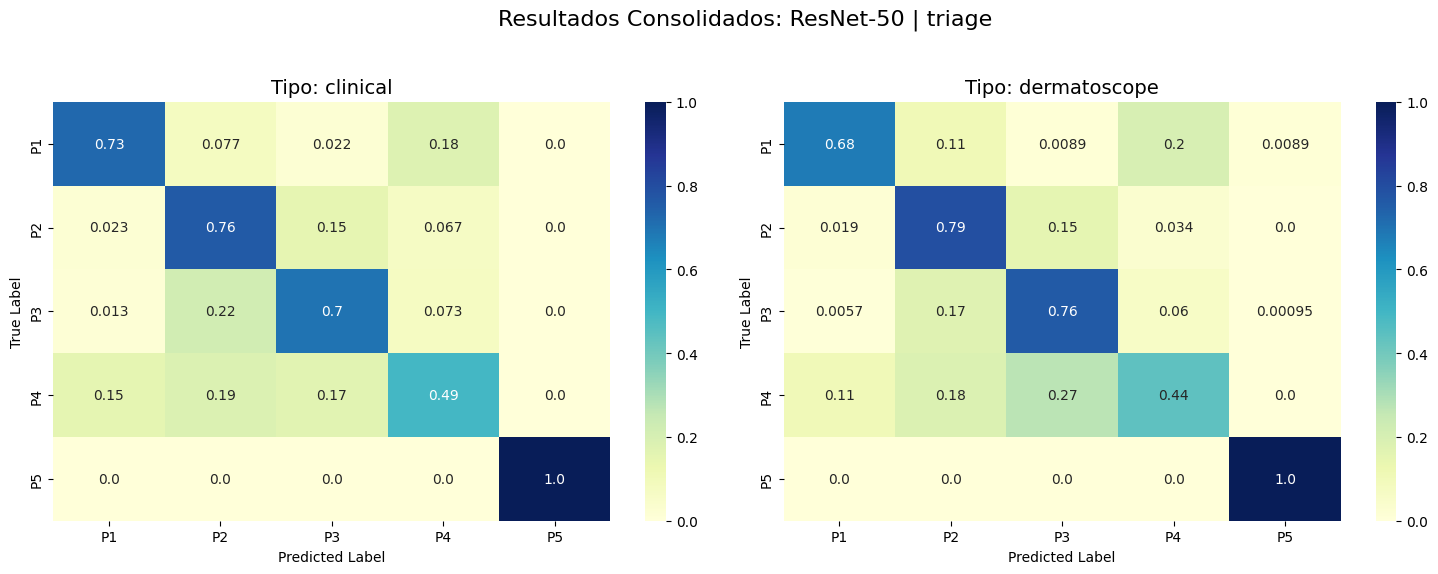

In [51]:
plot_comparative_confusion_matrix(df_pred, "ResNet-50", "triage")

#### MobileNet-v2

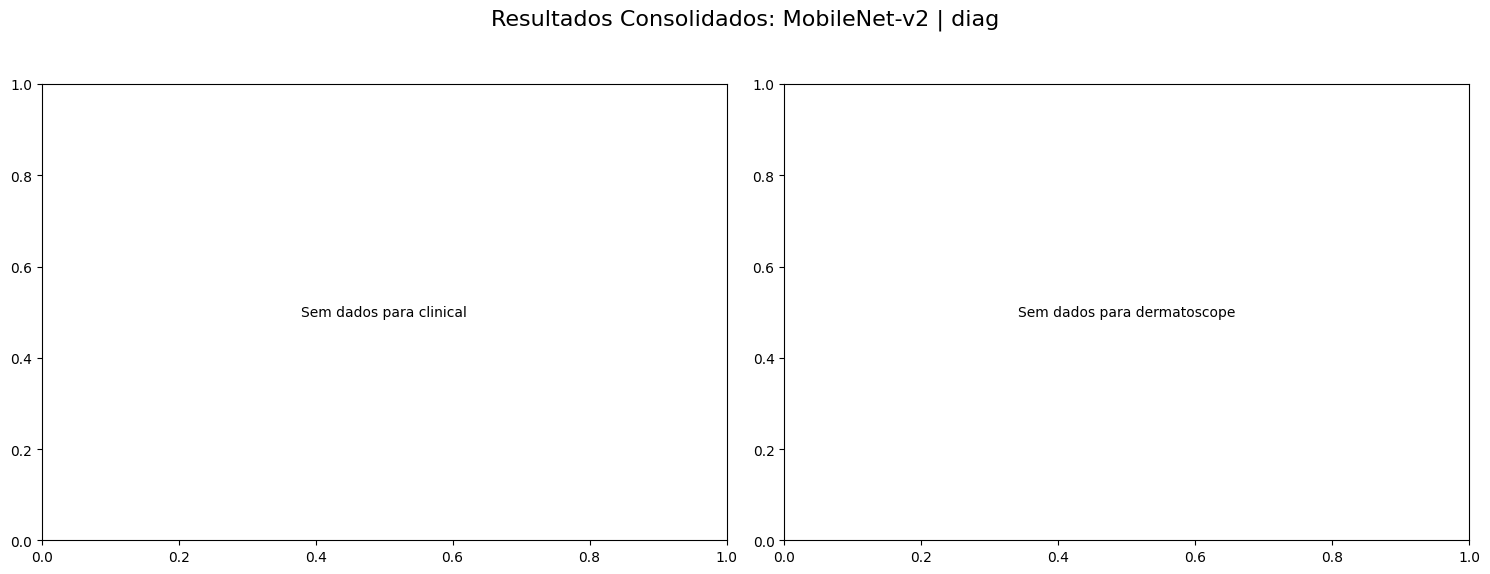

In [52]:
plot_comparative_confusion_matrix(df_pred, "MobileNet-v2", "diag")

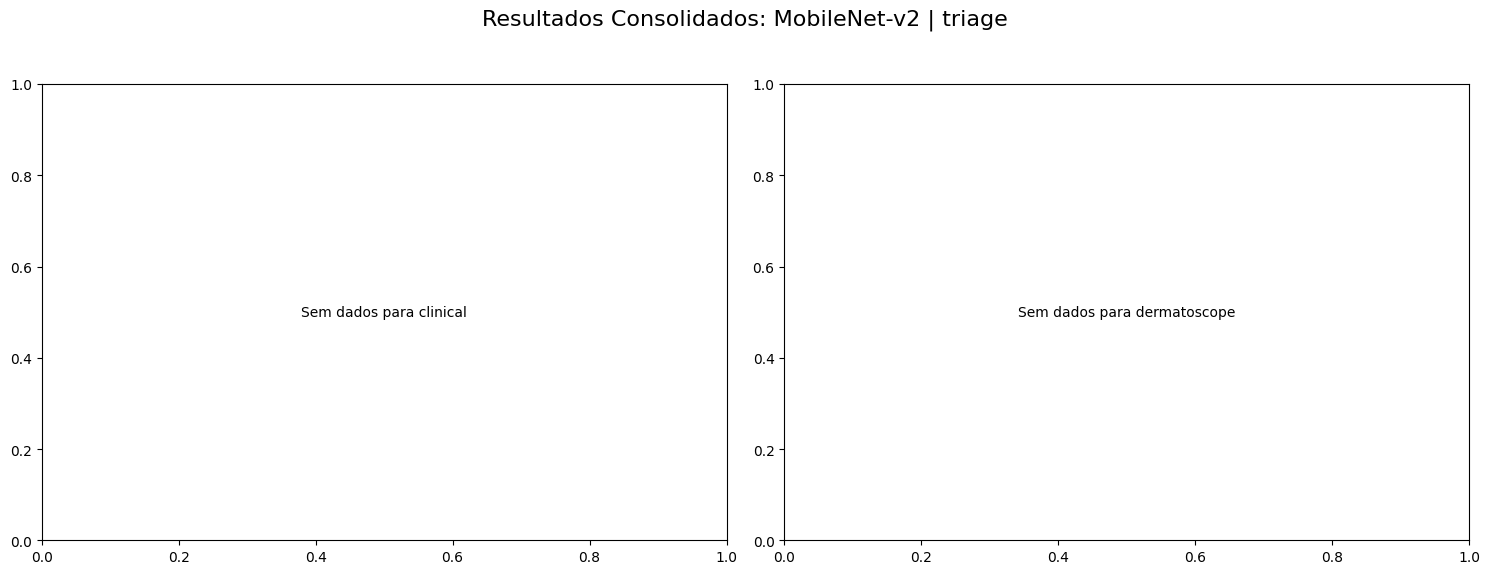

In [53]:
plot_comparative_confusion_matrix(df_pred, "MobileNet-v2", "triage")

### Validation

In [54]:
df_val = pd.DataFrame(columns=["backbone", "classifier", "image_type", "folder", "metric", "metric_value"])

In [55]:
base_path = '../'
for file in os.listdir(base_path):
    if os.path.isdir(os.path.join(base_path, file)) and file.startswith("results_"):
        path = os.path.join(base_path, file)
        parts = file.split("_")
        classifier = parts[1]
        image_type = parts[2]
        
        for subfile in os.listdir(path):
            path2 = os.path.join(path, subfile)
            if os.path.isdir(path2):
                parts = subfile.split("_")
                backbone = parts[0]

                for folder in os.listdir(path2):
                    path3 = os.path.join(path2, folder)
                    if os.path.isdir(path3):
                        folder_number = folder.split("_")[-2]
                        results_path = os.path.join(path3, "test_pred")
                        try:
                            results = getMetrics(os.path.join(results_path, "metrics.txt"))
                            for metric in results:
                                new_row = {
                                    "backbone": backbone,
                                    "classifier": classifier,
                                    "image_type": image_type,
                                    "folder": folder_number,
                                    "metric": metric[0],
                                    "metric_value": metric[1],
                                }
                                df_val.loc[len(df_val)] = new_row
                        except Exception as e:
                            pass

In [56]:
df_val['backbone'] = df_val['backbone'].map({
    'resnet-50': 'ResNet-50',
    'mobilenet': 'MobileNet-v2',
    'efficientnet-b4': 'EfficientNet-b4',
    'caformer': 'Caformer-s18',
    'davit': 'Davit-tiny',
    'maxvit': 'Maxvit-tiny',
    'mvitv2': 'Mvit2-small'
})

In [57]:
gerar_tabelas_latex(df_val, output_path='tabelas_val.txt')

Arquivo salvo com sucesso em: tabelas_val.txt
